# **Day 92: Project 2 - Crop-Type Mapping (Part 1): Satellite Time Series, Phenology and Transferability**
*Module 13 - Remote Sensing ML and Publication Projects*

Crops are identified by **when** they grow, more than by what they look like on one date. In eastern India, kharif rice is transplanted into flooded fields in July, maize is harvested in September, pigeon pea stays green into winter, and the rabi crops (wheat, mustard) follow from November. Monsoon clouds hide most optical images exactly when the kharif crops develop, so **Sentinel-1 SAR** becomes essential.

> **Working title**: *Phenology-based crop-type mapping from Sentinel-1/2 time series: how well do models transfer across regions and years?*

**Research questions**
- **RQ1**: Which time-series representation works best: gap-filled raw series, phenological metrics or harmonic coefficients? And which sensor: S2, S1 or both?
- **RQ2**: How much accuracy is lost when a model is applied to **another region** or **another year**?
- **RQ3** (Day 93): Do deep temporal models (TempCNN, LSTM, Transformer) help, and **how early in the season** can crops be mapped?

> Crops are recognised by their calendar: when they green up, peak and are harvested. We clean cloudy time series, smooth them, extract phenology metrics, and test whether a model trained in one region or year still works in another.
>
> *Example:* Rice greens up after July flooding and peaks in September, while wheat greens up only in December. The NDVI curve over the year tells them apart.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd, json, sys, time
from pathlib import Path
from scipy.signal import savgol_filter
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import f1_score, confusion_matrix
import rs_utils as ru
ru.pub_style()
SEED = 42
PROJ = Path("project2_crop"); (PROJ / "data").mkdir(parents=True, exist_ok=True); (PROJ / "outputs").mkdir(exist_ok=True)

## **1. The Data: Parcel Time Series**
Crop maps are usually made per **field parcel** (object-based): average all pixels inside the parcel for every date. This removes speckle and mixed edge pixels and matches how statistics are reported. In GEE this is one call:

```python
fields = ee.FeatureCollection("projects/your-project/assets/parcels_2024")
def parcel_means(img):
    return img.reduceRegions(collection=fields, reducer=ee.Reducer.mean(), scale=10).map(lambda f: f.set("date", img.date().format("YYYY-MM-dd")))
table = s2_masked.select(["B2","B3","B4","B5","B8","B11"]).map(parcel_means).flatten()   # export to Drive as CSV
```

Our simulated survey covers 3 regions x 2 years x 900 parcels with crop labels from a field survey (3% label errors, as in real surveys). It has Sentinel-2 every 5 days (NaN where cloud-masked) and Sentinel-1 every 12 days, from 1 June to 31 May. We save it in the same form as a GEE export would arrive.

In [2]:
parcels, s2, s2_days, s1, s1_days = ru.make_crop_dataset(seed=0)
gdf = gpd.GeoDataFrame(parcels.drop(columns=["crop_id_true", "variant"]), geometry=gpd.points_from_xy(parcels.x, parcels.y), crs=ru.CRS)
gdf.to_file(PROJ / "data/parcels.gpkg")
np.savez_compressed(PROJ / "data/timeseries.npz", s2=s2, s2_days=s2_days, s1=s1, s1_days=s1_days, s2_bands=ru.CROP_BANDS, s1_bands=["VV", "VH"])
parcels[["parcel_id", "crop_id_true", "variant"]].to_csv(PROJ / "data/_truth_SIMULATION_ONLY.csv", index=False)
print(f"{len(parcels)} parcels | S2 {s2.shape} ({np.isnan(s2[..., 0]).mean():.0%} cloud-masked) | S1 {s1.shape}")
pd.crosstab([parcels.year, parcels.region], parcels.crop)

5400 parcels | S2 (5400, 73, 6) (33% cloud-masked) | S1 (5400, 31, 2)


crop         maize  mustard  pigeon_pea  rice  wheat
year region                                         
2023 A         151      132          73   351    193
     B         106      127          76   398    193
     C         130      147         157   317    149
2024 A         151      134          80   374    161
     B         106      135          96   384    179
     C         139      120         181   307    153

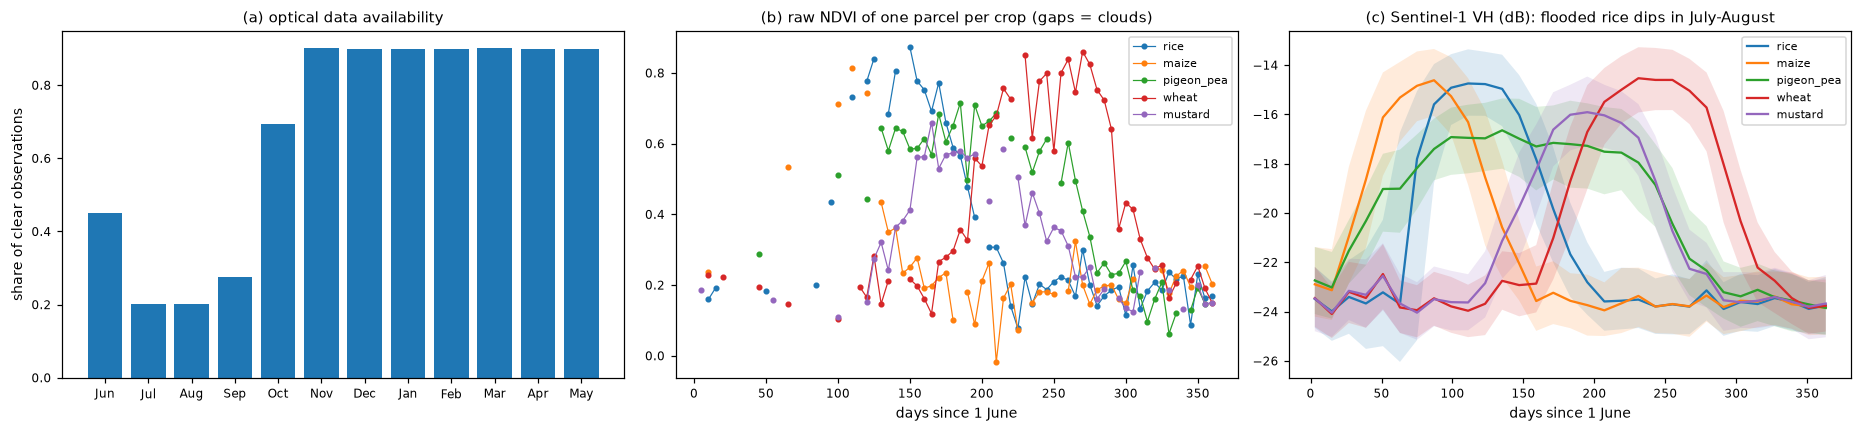

In [3]:
months = pd.date_range("2024-06-01", periods=12, freq="MS")
clear_by_month = [(~np.isnan(s2[:, (s2_days >= (m - months[0]).days) & (s2_days < (m - months[0]).days + 30), 0])).mean() for m in months]
nd_raw = (s2[..., 4] - s2[..., 2]) / (s2[..., 4] + s2[..., 2])
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
axes[0].bar([m.strftime("%b") for m in months], clear_by_month, color="tab:blue"); axes[0].set_ylabel("share of clear observations"); axes[0].set_title("(a) optical data availability")
for k, c in enumerate(ru.CROP_CLASSES):
    i = np.flatnonzero(parcels.crop_id == k)[0]
    axes[1].plot(s2_days, nd_raw[i], "o-", ms=3, lw=0.8, label=c)
axes[1].set_title("(b) raw NDVI of one parcel per crop (gaps = clouds)"); axes[1].set_xlabel("days since 1 June"); axes[1].legend(fontsize=7)
for k, c in enumerate(ru.CROP_CLASSES):
    q = np.percentile(s1[parcels.crop_id.values == k, :, 1], [25, 50, 75], axis=0)
    axes[2].plot(s1_days, q[1], label=c); axes[2].fill_between(s1_days, q[0], q[2], alpha=0.15)
axes[2].set_title("(c) Sentinel-1 VH (dB): flooded rice dips in July-August"); axes[2].set_xlabel("days since 1 June"); axes[2].legend(fontsize=7)
plt.tight_layout(); fig.savefig(PROJ / "outputs/fig1_data_overview.png", dpi=300, bbox_inches="tight"); plt.show()

## **2. A Shared Time-Series Module**
All preprocessing goes into `project2_crop/crop_ts.py`, which Day 93 reuses:
- **outlier screening**: undetected thin clouds raise the blue band, so we flag observations whose B2 exceeds a smooth fit by more than 0.03 and refit (an iterative upper-envelope rule)
- **Whittaker smoother** (Eilers 2003): minimise sum w_t (y_t - z_t)^2 + lambda sum (Delta^2 z_t)^2. Weights w_t = 0 at gaps, so it fills gaps and smooths in one linear solve
- **harmonic regression**: y(t) = c + sum_k (a_k cos(2 pi k t / 365) + b_k sin(2 pi k t / 365)), fitted to the valid observations only
- **phenological metrics** per season window, and **SAR metrics**

In [4]:
%%writefile project2_crop/crop_ts.py
"""Time-series preprocessing and features for Project 2 (crop types). Written by Day 92, used by Day 93."""
import numpy as np

S2_BANDS = ["B2", "B3", "B4", "B5", "B8", "B11"]

def whittaker(Y, lam=20.0, d=2, chunk=500):
    """Weighted Whittaker smoother along axis 1 of Y (N, T); NaN = missing (weight 0). Returns (N, T)."""
    N, T = Y.shape
    D = np.diff(np.eye(T), d, axis=0); P = lam * D.T @ D
    w_all = (~np.isnan(Y)).astype(np.float64); Y0 = np.nan_to_num(Y.astype(np.float64))
    out = np.empty((N, T))
    for s in range(0, N, chunk):
        w = w_all[s:s + chunk]
        A = P[None] + w[:, :, None] * np.eye(T)[None] + 1e-9 * np.eye(T)[None]
        out[s:s + chunk] = np.linalg.solve(A, (w * Y0[s:s + chunk])[..., None])[..., 0]
    return out

def screen_outliers(s2, thresh=0.03, lam=20.0, n_iter=2):
    """Flag undetected thin clouds: B2 well above a smooth fit of B2. Returns a copy of s2 with outliers set to NaN."""
    s2 = s2.copy()
    for _ in range(n_iter):
        b2 = s2[..., 0]; fit = whittaker(b2, lam)
        bad = (b2 - fit) > thresh
        s2[bad] = np.nan
    return s2

def ndvi(s2):
    return (s2[..., 4] - s2[..., 2]) / (s2[..., 4] + s2[..., 2])

def smooth_all(s2, lam=20.0):
    """Whittaker-smooth every band and NDVI. Returns (N, T, 7): 6 bands + NDVI."""
    bands = [whittaker(s2[..., b], lam) for b in range(s2.shape[-1])]
    return np.stack(bands + [whittaker(ndvi(s2), lam)], axis=-1).astype(np.float32)

def harmonic_fit(y, days, n_harm=3, period=365.0):
    """Least-squares harmonic coefficients per row of y (N, T) using valid observations. Returns (N, 1 + 2 n_harm)."""
    t = 2 * np.pi * np.asarray(days) / period
    X = np.column_stack([np.ones_like(t)] + [f(k * t) for k in range(1, n_harm + 1) for f in (np.cos, np.sin)])
    out = np.zeros((y.shape[0], X.shape[1]))
    for i, row in enumerate(y):
        ok = ~np.isnan(row)
        if ok.sum() >= X.shape[1] + 2:
            out[i] = np.linalg.lstsq(X[ok], row[ok], rcond=None)[0]
    return out

def season_metrics(v, days, window, prefix, frac=0.5):
    """Phenological metrics of a smoothed index v (N, T) within a day window: threshold method at frac of the amplitude."""
    m = (days >= window[0]) & (days <= window[1]); v = v[:, m]; d = days[m]; step = np.median(np.diff(d))
    base = np.minimum(v[:, :3].mean(1), v[:, -3:].mean(1)); peak = v.max(1); amp = peak - base
    above = v >= (base + frac * amp)[:, None]
    sos = d[above.argmax(1)]; eos = d[len(d) - 1 - above[:, ::-1].argmax(1)]
    return {f"{prefix}_SOS": sos, f"{prefix}_POS": d[v.argmax(1)], f"{prefix}_EOS": eos, f"{prefix}_LOS": eos - sos,
            f"{prefix}_peak": peak, f"{prefix}_amplitude": amp, f"{prefix}_integral": np.clip(v - base[:, None], 0, None).sum(1) * step,
            f"{prefix}_greenup_rate": np.max(np.diff(v, axis=1), 1) / step, f"{prefix}_senescence_rate": -np.min(np.diff(v, axis=1), 1) / step}

def sar_metrics(s1, days):
    vv, vh = s1[..., 0], s1[..., 1]
    w = lambda a, b: (days >= a) & (days <= b)
    return {"VH_min_JulAug": vh[:, w(30, 92)].min(1), "VH_mean_Sep": vh[:, w(92, 122)].mean(1), "VH_max_kharif": vh[:, w(0, 180)].max(1),
            "VH_mean_rabi": vh[:, w(180, 300)].mean(1), "VV_mean_rabi": vv[:, w(180, 300)].mean(1),
            "VHminusVV_Sep": (vh - vv)[:, w(92, 122)].mean(1), "VH_range": vh.max(1) - vh.min(1)}

def to_grid(arr, days, grid):
    """Linear interpolation of a smoothed (N, T, C) array onto a regular day grid."""
    return np.stack([np.stack([np.interp(grid, days, arr[i, :, c]) for c in range(arr.shape[2])], -1) for i in range(arr.shape[0])])

Writing project2_crop/crop_ts.py


In [5]:
sys.path.insert(0, str(PROJ))
import crop_ts as ct
t0 = time.perf_counter()
s2_clean = ct.screen_outliers(s2)
print(f"outlier screening removed {(np.isnan(s2_clean[..., 0]).mean() - np.isnan(s2[..., 0]).mean()):.2%} of all observations ({time.perf_counter() - t0:.1f} s)")
sm = ct.smooth_all(s2_clean); nd_sm = sm[..., -1]
print(f"smoothed array {sm.shape} in {time.perf_counter() - t0:.1f} s")

outlier screening removed 3.98% of all observations (0.6 s)


smoothed array (5400, 73, 7) in 2.9 s


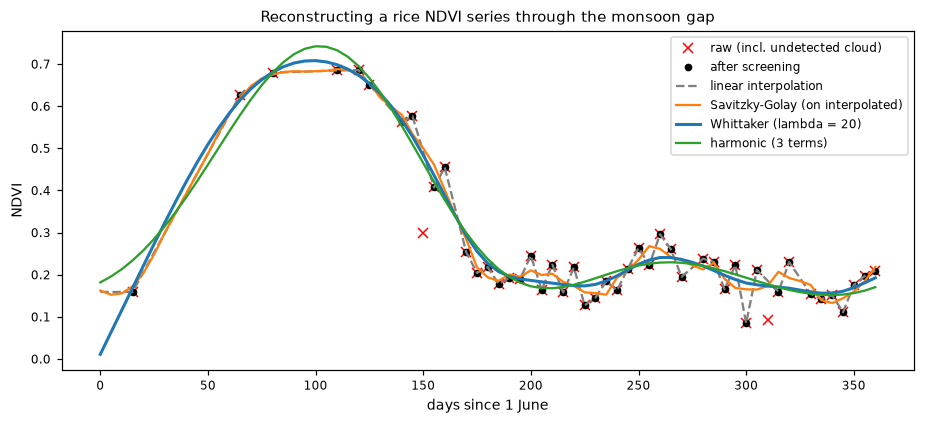

In [6]:
i = np.flatnonzero((parcels.crop == "rice").values)[3]
nd_clean = ct.ndvi(s2_clean)
plt.figure(figsize=(10, 4))
plt.plot(s2_days, nd_raw[i], "x", c="r", label="raw (incl. undetected cloud)"); plt.plot(s2_days, nd_clean[i], "o", c="k", ms=4, label="after screening")
lin = np.interp(s2_days, s2_days[~np.isnan(nd_clean[i])], nd_clean[i][~np.isnan(nd_clean[i])])
plt.plot(s2_days, lin, "--", c="gray", label="linear interpolation")
plt.plot(s2_days, savgol_filter(lin, 7, 2), c="tab:orange", label="Savitzky-Golay (on interpolated)")
plt.plot(s2_days, nd_sm[i], c="tab:blue", lw=2, label="Whittaker (lambda = 20)")
hc = ct.harmonic_fit(nd_clean[i:i + 1], s2_days)[0]; tt = 2 * np.pi * s2_days / 365
plt.plot(s2_days, hc[0] + sum(hc[2 * k - 1] * np.cos(k * tt) + hc[2 * k] * np.sin(k * tt) for k in range(1, 4)), c="tab:green", label="harmonic (3 terms)")
plt.xlabel("days since 1 June"); plt.ylabel("NDVI"); plt.title("Reconstructing a rice NDVI series through the monsoon gap"); plt.legend(fontsize=8); plt.show()

## **3. Features: Four Representations**
| Set | Content | Size |
|---|---|---|
| **A: raw S2** | Whittaker-smoothed 6 bands + NDVI on a 10-day grid | 37 x 7 |
| **B: phenology** | kharif and rabi metrics (SOS, POS, EOS, LOS, peak, amplitude, integral, rates) + SAR metrics | 25 |
| **C: harmonic** | 3-harmonic coefficients of NDVI and of each band | 49 |
| **D: raw S1** | VV, VH on the 10-day grid | 37 x 2 |
| **A + D** | optical + SAR | 333 |

In [7]:
grid = np.arange(0, 365, 10)
A = ct.to_grid(sm, s2_days, grid).reshape(len(parcels), -1)
s1_grid = ct.to_grid(s1, s1_days, grid); D = s1_grid.reshape(len(parcels), -1)
phen = {**ct.season_metrics(nd_sm, s2_days, (0, 180), "kharif"), **ct.season_metrics(nd_sm, s2_days, (150, 330), "rabi"), **ct.sar_metrics(s1, s1_days)}
B = pd.DataFrame(phen)
C = np.hstack([ct.harmonic_fit(ct.ndvi(s2_clean), s2_days)] + [ct.harmonic_fit(s2_clean[..., b], s2_days) for b in range(6)])
feature_sets = {"A raw S2": A, "B phenology + SAR metrics": B.values, "C harmonic": C, "D raw S1": D, "A + D (S2 + S1)": np.hstack([A, D])}
print({k: v.shape[1] for k, v in feature_sets.items()})
B.assign(crop=parcels.crop).groupby("crop")[["kharif_SOS", "kharif_POS", "kharif_EOS", "rabi_POS", "VH_min_JulAug", "VH_mean_rabi"]].median().round(1)

{'A raw S2': 259, 'B phenology + SAR metrics': 25, 'C harmonic': 49, 'D raw S1': 74, 'A + D (S2 + S1)': 333}


,kharif_SOS,kharif_POS,kharif_EOS,rabi_POS,VH_min_JulAug,VH_mean_rabi
crop,,,,,,
maize,35.0,80.0,125.0,150.0,-18.900000,-23.700001
mustard,150.0,180.0,180.0,185.0,-25.000000,-18.900000
pigeon_pea,55.0,140.0,180.0,175.0,-20.799999,-19.299999
rice,65.0,115.0,165.0,150.0,-25.900000,-23.299999
wheat,165.0,180.0,180.0,240.0,-25.000000,-16.000000


## **4. Validation Schemes for Crop Maps**
| Scheme | Train | Test | Question it answers |
|---|---|---|---|
| Spatial CV (2024) | 2 km blocks, 5 folds | held-out blocks | accuracy within the surveyed regions and year |
| Leave-one-region-out (2024) | 2 regions | the 3rd region | can we map a district without field data? |
| Leave-one-year-out | all of 2024 | all of 2023 | can last year's model map this year (before any survey)? |

The test labels are the survey labels, which contain about 3% errors. That caps the achievable score slightly below 1, as in any real study.

In [8]:
y = parcels["crop_id"].values; year = parcels["year"].values; region = parcels["region"].values
blocks = ru.spatial_blocks(parcels.x.values, parcels.y.values, 2000)
rf = lambda: RandomForestClassifier(300, n_jobs=-1, random_state=SEED, min_samples_leaf=1)

def evaluate(X):
    res = {}
    m24 = year == 2024
    idx = np.flatnonzero(m24)
    pred = cross_val_predict(rf(), X[idx], y[idx], cv=GroupKFold(5), groups=blocks[idx])
    res["spatial CV 2024"] = f1_score(y[idx], pred, average="macro")
    loro = []
    for r in ["A", "B", "C"]:
        tr, te = m24 & (region != r), m24 & (region == r)
        loro.append(f1_score(y[te], rf().fit(X[tr], y[tr]).predict(X[te]), average="macro"))
    res["leave-region-out (mean)"] = np.mean(loro); res["LORO A / B / C"] = " / ".join(f"{v:.3f}" for v in loro)
    res["leave-year-out (2024 -> 2023)"] = f1_score(y[~m24], rf().fit(X[m24], y[m24]).predict(X[~m24]), average="macro")
    return res

t0 = time.perf_counter()
table = pd.DataFrame({k: evaluate(np.asarray(v, np.float32)) for k, v in feature_sets.items()}).T
print(f"done in {time.perf_counter() - t0:.0f} s")
table.to_csv(PROJ / "outputs/table1_feature_sets.csv"); table

done in 27 s


,spatial CV 2024,leave-region-out (mean),LORO A / B / C,leave-year-out (2024 -> 2023)
A raw S2,0.95792,0.941854,0.961 / 0.895 / 0.970,0.927623
B phenology + SAR metrics,0.952328,0.934641,0.949 / 0.894 / 0.961,0.912559
C harmonic,0.961052,0.942852,0.959 / 0.902 / 0.968,0.931019
D raw S1,0.937934,0.912414,0.936 / 0.863 / 0.938,0.885666
A + D (S2 + S1),0.957586,0.941565,0.962 / 0.894 / 0.969,0.924316


Read the table along both axes:
- **Down the columns**: the representations and sensors. On full-season data the S2 representations are close. SAR alone is a few points lower, but it is the only source with data during the monsoon (Section 7, Day 93).
- **Across the rows**: transfer costs accuracy, most for region B (sown about two weeks later than A) and for the late-monsoon year 2023, where every representation loses roughly 3-5 points. Phenological metrics do **not** escape the shift, because their SOS, POS and EOS are calendar dates that move with the monsoon. Practice Problem 4 removes that shift, and Day 93 attacks it with temporal augmentation.

A paper should report all three columns. "Spatial CV within one year" alone describes a situation that rarely occurs in practice, when a model trained on last year's survey must map this year.

## **5. Where Do Errors Occur?**

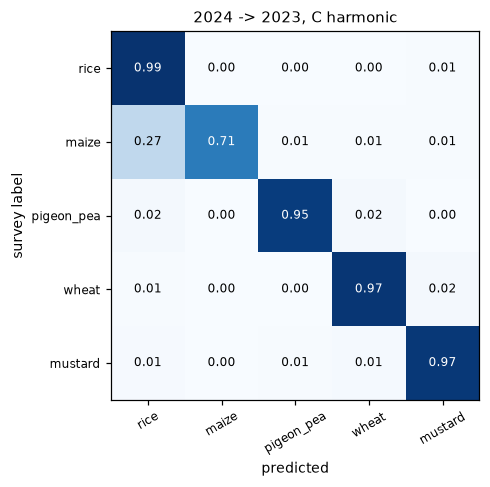

2023 accuracy against survey labels 0.937 | against the true crops (simulation only) 0.955
                               size   mean
true crop  variant                        
maize      standard             382  0.730
mustard    standard             402  0.995
pigeon_pea intercropped_maize   104  1.000
           standard             196  1.000
rice       direct_seeded        279  0.996
           standard             794  0.994
wheat      late_sown            120  1.000
           standard             423  0.976


In [9]:
best_set = table["leave-year-out (2024 -> 2023)"].astype(float).idxmax()
Xb = np.asarray(feature_sets[best_set], np.float32); m24 = year == 2024
pred23 = rf().fit(Xb[m24], y[m24]).predict(Xb[~m24])
cm = confusion_matrix(y[~m24], pred23, normalize="true")
fig, ax = plt.subplots(figsize=(5.5, 4.5)); ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
for i_ in range(5):
    for j in range(5): ax.text(j, i_, f"{cm[i_, j]:.2f}", ha="center", va="center", fontsize=8, color="w" if cm[i_, j] > 0.6 else "k")
ax.set_xticks(range(5), ru.CROP_CLASSES, rotation=30); ax.set_yticks(range(5), ru.CROP_CLASSES); ax.set_xlabel("predicted"); ax.set_ylabel("survey label")
ax.set_title(f"2024 -> 2023, {best_set}"); plt.tight_layout(); plt.show()
truth = pd.read_csv(PROJ / "data/_truth_SIMULATION_ONLY.csv")
yt23 = truth["crop_id_true"].values[~m24]
print(f"2023 accuracy against survey labels {np.mean(pred23 == y[~m24]):.3f} | against the true crops (simulation only) {np.mean(pred23 == yt23):.3f}")
print(pd.DataFrame({"true crop": [ru.CROP_CLASSES[k] for k in yt23], "variant": truth["variant"].values[~m24], "correct": pred23 == yt23})
      .groupby(["true crop", "variant"])["correct"].agg(["size", "mean"]).round(3))

The confusion matrix shows which crops are confused after the calendar shift. Scoring against the **true** crops (possible only in simulation) separates two things: errors that are really survey-label noise, and real model errors. The breakdown by management **variant** shows which practices are hardest. In a real study, field-survey attributes such as sowing method or intercropping play this role. The relative area errors in Section 6 point to the same weak class.

## **6. Crop Statistics: Area-Weighted Accuracy**
Agencies need crop **areas**, so large parcels matter more than small ones. Weight each parcel by its area.

In [10]:
area = parcels.loc[~m24, "area_ha"].values
print(f"2023 parcels: unweighted accuracy {np.mean(pred23 == y[~m24]):.3f} | area-weighted accuracy {np.average(pred23 == y[~m24], weights=area):.3f}")
est = pd.DataFrame({"survey area (ha)": pd.Series(area).groupby(y[~m24]).sum(), "mapped area (ha)": pd.Series(area).groupby(pred23).sum()}).reindex(range(5))
est.index = ru.CROP_CLASSES; est["relative error %"] = (100 * (est["mapped area (ha)"] - est["survey area (ha)"]) / est["survey area (ha)"]).round(1)
est.round(1)

2023 parcels: unweighted accuracy 0.937 | area-weighted accuracy 0.938


,survey area (ha),mapped area (ha),relative error %
rice,709.9,784.2,10.5
maize,254.9,178.5,-30.0
pigeon_pea,189.0,184.9,-2.2
wheat,364.0,366.0,0.5
mustard,268.2,272.3,1.5


# **Part 2: Going Deeper**

## **7. Which Gap-Filling Method Reconstructs Best?**
Test it directly: hide 20% of the clear observations, reconstruct them with each method, and measure the error. Report this in a methods section when we choose a smoother.

In [11]:
rng = np.random.default_rng(SEED)
y_true = ct.ndvi(s2_clean); hide = (~np.isnan(y_true)) & (rng.random(y_true.shape) < 0.2)
y_obs = np.where(hide, np.nan, y_true)
def lin_fill(Y):
    return np.array([np.interp(s2_days, s2_days[~np.isnan(r)], r[~np.isnan(r)]) for r in Y])
recon = {"linear": lin_fill(y_obs), "Savitzky-Golay (7, 2)": savgol_filter(lin_fill(y_obs), 7, 2, axis=1)}
for lam in [2, 20, 200]:
    recon[f"Whittaker lambda={lam}"] = ct.whittaker(y_obs, lam)
hc_all = ct.harmonic_fit(y_obs, s2_days); tt = 2 * np.pi * s2_days / 365
basis = np.column_stack([np.ones_like(tt)] + [f(k * tt) for k in range(1, 4) for f in (np.cos, np.sin)])
recon["harmonic (3)"] = hc_all @ basis.T
monsoon = (s2_days > 30) & (s2_days < 130)
pd.DataFrame({k: {"RMSE all hidden": np.sqrt(np.mean((v[hide] - y_true[hide]) ** 2)),
                  "RMSE hidden in monsoon": np.sqrt(np.mean((v[hide & monsoon[None]] - y_true[hide & monsoon[None]]) ** 2))} for k, v in recon.items()}).T.round(4)

,RMSE all hidden,RMSE hidden in monsoon
linear,0.0714,0.1075
"Savitzky-Golay (7, 2)",0.0715,0.1075
Whittaker lambda=2,0.0830,0.1173
Whittaker lambda=20,0.0783,0.1120
Whittaker lambda=200,0.0883,0.1347
harmonic (3),0.0702,0.1128


Note two things. First, the error is measured against **noisy** observations, so no method can get below the observation noise. Second, no method wins everywhere. Strong smoothing (lambda = 200) blurs the sharp green-up and harvest transitions and clearly loses. Linear interpolation, light Whittaker smoothing and the 3-harmonic fit are close overall, and all of them struggle inside the monsoon gap, where there is almost no optical data. That is the argument for SAR, not for a cleverer smoother. Choose the method and lambda with exactly this hold-out test on **our** data. The Whittaker smoother's practical advantages are that gap filling and smoothing happen in one step, with a single interpretable parameter.

## **Practice Problems**
1. Compute phenology metrics with a 20% (instead of 50%) amplitude threshold. Do SOS/EOS shift, and does leave-year-out accuracy change?
2. Train on 2024 region A only and test on region B for feature sets A and B. Which transfers better?
3. Which **single** SAR metric best separates rice from maize? Rank the SAR metrics by univariate F statistic (`f_classif`).
4. *(Advanced)* Standardise each phenology date metric **per region-year** (subtract the median SOS of that region-year) and re-run leave-year-out. Does removing the calendar shift help?

In [12]:
# Solution 1
phen20 = pd.DataFrame({**ct.season_metrics(nd_sm, s2_days, (0, 180), "kharif", frac=0.2), **ct.season_metrics(nd_sm, s2_days, (150, 330), "rabi", frac=0.2), **ct.sar_metrics(s1, s1_days)})
print("median kharif SOS (50% vs 20%):", float(np.median(B.kharif_SOS)), float(np.median(phen20.kharif_SOS)))
print("leave-year-out F1 with 20% threshold:", round(evaluate(phen20.values.astype(np.float32))["leave-year-out (2024 -> 2023)"], 3),
      "| with 50%:", round(table.loc["B phenology + SAR metrics", "leave-year-out (2024 -> 2023)"], 3))

median kharif SOS (50% vs 20%): 75.0 50.0


leave-year-out F1 with 20% threshold: 0.905 | with 50%: 0.913


In [13]:
# Solution 2
tr, te = (year == 2024) & (region == "A"), (year == 2024) & (region == "B")
for k in ["A raw S2", "B phenology + SAR metrics"]:
    X_ = np.asarray(feature_sets[k], np.float32)
    print(f"{k:<28} A -> B macro F1 {f1_score(y[te], rf().fit(X_[tr], y[tr]).predict(X_[te]), average='macro'):.3f}")

A raw S2                     A -> B macro F1 0.901


B phenology + SAR metrics    A -> B macro F1 0.896


In [14]:
# Solution 3
from sklearn.feature_selection import f_classif
sar_cols = list(ct.sar_metrics(s1, s1_days).keys()); rm = np.isin(y, [0, 1])
F_, p_ = f_classif(B.loc[rm, sar_cols], y[rm])
print(pd.Series(F_, index=sar_cols).sort_values(ascending=False).round(1))

VH_min_JulAug    1776.7
VH_range          223.6
VH_mean_Sep        65.1
VHminusVV_Sep      41.2
VH_mean_rabi       30.0
VV_mean_rabi        3.6
VH_max_kharif       0.1
dtype: float64


In [15]:
# Solution 4
Bn = B.astype(float); date_cols = [c for c in B.columns if c.endswith(("_SOS", "_POS", "_EOS"))]
for (yr, rg), g in parcels.groupby(["year", "region"]):
    Bn.loc[g.index, date_cols] = B.loc[g.index, date_cols] - B.loc[g.index, date_cols].median()
print("leave-year-out F1, region-year-normalised dates:", round(evaluate(Bn.values.astype(np.float32))["leave-year-out (2024 -> 2023)"], 3))
print("Normalising needs no labels from the target year (only the target images), so it is a legitimate, simple domain adaptation.")

leave-year-out F1, region-year-normalised dates: 0.921
Normalising needs no labels from the target year (only the target images), so it is a legitimate, simple domain adaptation.


## **Key References**
- Eilers, P. H. C. (2003). A perfect smoother. *Analytical Chemistry*, 75(14), 3631-3636.
- Jönsson, P., & Eklundh, L. (2004). TIMESAT - a program for analyzing time-series of satellite sensor data. *Computers & Geosciences*, 30(8), 833-845.
- Zeng, L., Wardlow, B. D., Xiang, D., Hu, S., & Li, D. (2020). A review of vegetation phenological metrics extraction using time-series, multispectral satellite data. *Remote Sensing of Environment*, 237, 111511.
- Veloso, A. et al. (2017). Understanding the temporal behavior of crops using Sentinel-1 and Sentinel-2-like data for agricultural applications. *Remote Sensing of Environment*, 199, 415-426.
- Defourny, P. et al. (2019). Near real-time agriculture monitoring at national scale at parcel resolution: Performance assessment of the Sen2-Agri automated system in various cropping systems around the world. *Remote Sensing of Environment*, 221, 551-568.
- Inglada, J., Vincent, A., Arias, M., & Marais-Sicre, C. (2016). Improved early crop type identification by joint use of high temporal resolution SAR and optical image time series. *Remote Sensing*, 8(5), 362.
- Jakubauskas, M. E., Legates, D. R., & Kastens, J. H. (2002). Crop identification using harmonic analysis of time-series AVHRR NDVI data. *Computers and Electronics in Agriculture*, 37(1-3), 127-139.